# Parallel Trends Test (Smaller Matched Sample)
This notebook tests the parallel trends assumption using only the matched sample in smaller_dataset/matched_sample.csv.

## Overview

This notebook validates the parallel-trends assumption using only the matched smaller-sample dataset. The goal is to test whether treated and matched control hospitals show similar pre-treatment outcome dynamics before merger exposure.

## Staggered DiD Design Context

Treatment timing is staggered across hospitals, so pre-trend diagnostics are evaluated using pre-treatment observations relative to each treated hospital's merger timing. We use fiscal-year trends and a formal interaction-based test to assess whether treated and control groups evolve similarly before treatment.

## Objectives

- Load and verify the matched panel from smaller_dataset/matched_sample.csv
- Construct the transformed outcome log(1 + cost_per_discharge)
- Compare treated vs control trends visually in full and pre-treatment samples
- Run a formal pre-period interaction test with robust standard errors
- Summarize whether there is statistical evidence against parallel pre-trends

## Dataset Description

The analysis uses smaller_dataset/matched_sample.csv only. Core fields include PRVDR_NUM, treated, fiscal_year, years_to_merger, and cost_per_discharge. No raw unmatched sample is used in this notebook.

## Key Considerations

- Parallel trends concerns similarity in slopes, not necessarily identical baseline levels
- Visual diagnostics and formal hypothesis tests should be interpreted jointly
- Restricting to pre-period observations is essential for valid pre-trend testing
- Robust (HC1) standard errors help with heteroskedasticity in hospital-level outcomes

## Outcome

By the end of this notebook, you get a visual pre-trend diagnostic and a joint interaction F-test result, followed by a direct conclusion on the parallel-trends assumption at the 5% significance level.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

## Step 1 - Load Data

In [2]:
DATA_PATH = "matched_sample.csv"
df = pd.read_csv(DATA_PATH)
hosp_status = df.groupby("PRVDR_NUM", as_index=False)["treated"].max()
n_treated = int((hosp_status["treated"] == 1).sum())
n_control = int((hosp_status["treated"] == 0).sum())
print("Shape:", df.shape)
print("Unique treated hospitals:", n_treated)
print("Unique control hospitals:", n_control)

Shape: (16071, 11)
Unique treated hospitals: 890
Unique control hospitals: 890


## Step 2 - Prepare Variables

In [ ]:
analysis_df = df.copy()
analysis_df["log_cost_per_discharge"] = np.log1p(analysis_df["cost_per_discharge"])
analysis_df = analysis_df.dropna(
    subset=["log_cost_per_discharge", "treated", "fiscal_year"]
).copy()
analysis_df["treated"] = analysis_df["treated"].astype(int)
analysis_df["fiscal_year"] = analysis_df["fiscal_year"].astype(int)
print("Prepared shape:", analysis_df.shape)
analysis_df[["treated", "fiscal_year", "log_cost_per_discharge"]].dtypes

Prepared shape: (16071, 12)


treated                     int64
fiscal_year                 int64
log_cost_per_discharge    float64
dtype: object

## Step 3 - Visual Parallel Trends Check (Full Matched Sample)

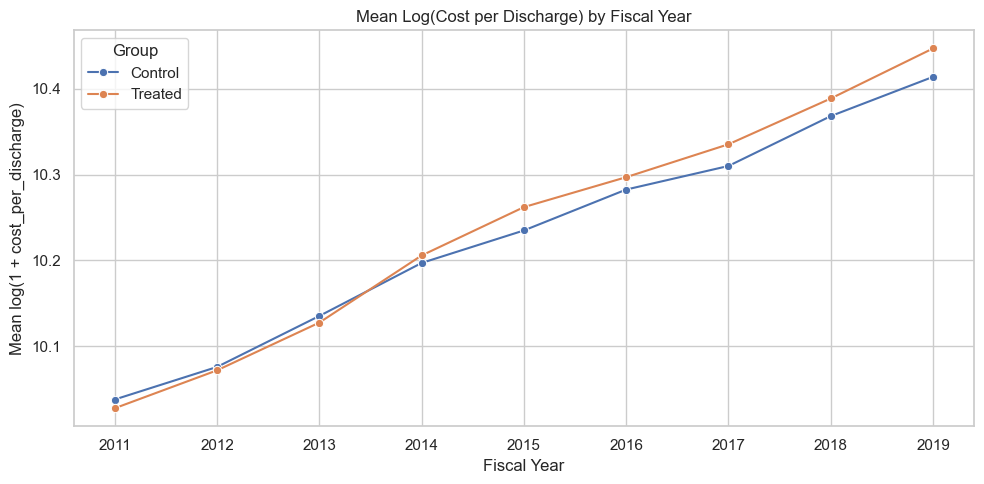

In [ ]:
trend_full = analysis_df.groupby(["fiscal_year", "treated"], as_index=False)[
    "log_cost_per_discharge"
].mean()
trend_full["Group"] = trend_full["treated"].map({0: "Control", 1: "Treated"})
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=trend_full,
    x="fiscal_year",
    y="log_cost_per_discharge",
    hue="Group",
    marker="o",
)
plt.title("Mean Log(Cost per Discharge) by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Mean log(1 + cost_per_discharge)")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

## Step 4 - Pre-Period Restriction and Plot

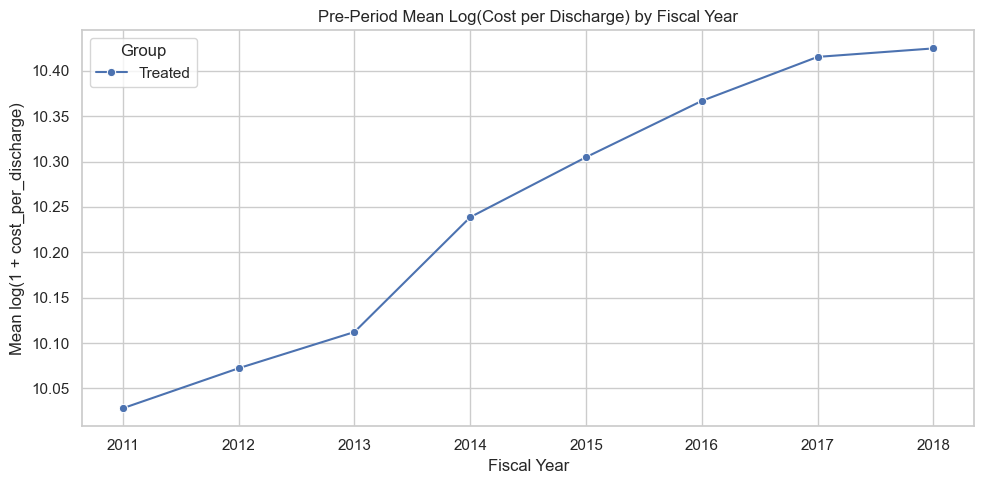

In [ ]:
pre_df = analysis_df[analysis_df["years_to_merger"] < 0].copy()
trend_pre = pre_df.groupby(["fiscal_year", "treated"], as_index=False)[
    "log_cost_per_discharge"
].mean()
trend_pre["Group"] = trend_pre["treated"].map({0: "Control", 1: "Treated"})
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=trend_pre, x="fiscal_year", y="log_cost_per_discharge", hue="Group", marker="o"
)
plt.title("Pre-Period Mean Log(Cost per Discharge) by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Mean log(1 + cost_per_discharge)")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

## Step 5 - Formal Parallel Trends Test (OLS, HC1)

In [ ]:
pt_model = smf.ols(
    "log_cost_per_discharge ~ treated + C(fiscal_year) + treated:C(fiscal_year)",
    data=pre_df,
).fit(cov_type="HC1")
print("Model estimated on pre-period observations.")
print("N observations:", int(pt_model.nobs))
print("R-squared:", round(pt_model.rsquared, 4))

Model estimated on pre-period observations.
N observations: 3972
R-squared: 0.0567


## Step 6 - Joint F-Test on Interaction Terms

In [ ]:
interaction_terms = [
    name for name in pt_model.params.index if "treated:C(fiscal_year)" in name
]
hypothesis = " = 0, ".join(interaction_terms) + " = 0"
f_test = pt_model.f_test(hypothesis)
f_stat = float(np.asarray(f_test.fvalue).squeeze())
p_val = float(np.asarray(f_test.pvalue).squeeze())
print("Number of interaction terms:", len(interaction_terms))
print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_val, 6))

Number of interaction terms: 7
F-statistic: 0.991
p-value: 0.421577


/Users/far/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 7, but rank is 5
  warnings.warn('covariance of constraints does not have full '


## Step 7 - Conclusion

In [ ]:
if p_val < 0.05:
    print("Conclusion: Reject parallel trends at 5% significance.")
else:
    print(
        "Conclusion: No statistical evidence against parallel trends at 5% significance."
    )

Conclusion: No statistical evidence against parallel trends at 5% significance.


## Step 8 - Optional Interaction Table

In [ ]:
interaction_table = pd.DataFrame(
    {
        "term": interaction_terms,
        "coef": [pt_model.params[t] for t in interaction_terms],
        "p_value": [pt_model.pvalues[t] for t in interaction_terms],
    }
)
interaction_table.sort_values("term").reset_index(drop=True)

,term,coef,p_value
0,treated:C(fiscal_year)[T.2012],-4.531220e+11,0.321107
1,treated:C(fiscal_year)[T.2013],8.507907e+11,0.325333
2,treated:C(fiscal_year)[T.2014],4.858853e+11,0.315190
3,treated:C(fiscal_year)[T.2015],-2.426844e+10,0.201880
4,treated:C(fiscal_year)[T.2016],-2.640388e+12,0.325223
5,treated:C(fiscal_year)[T.2017],1.116914e+10,0.212350
6,treated:C(fiscal_year)[T.2018],-1.378698e+10,0.212908


## Summary of Findings

This notebook evaluated the parallel-trends assumption on the matched smaller sample using both visual diagnostics and a formal pre-period interaction test.

### Visual Evidence

- Fiscal-year mean outcome paths for treated and control hospitals were compared in the full matched sample and in the pre-treatment subsample.
- The pre-period plot provides the primary visual diagnostic for whether treated and control groups move similarly before treatment.

### Statistical Evidence

- A robust OLS specification with treated-by-year interactions was estimated on pre-treatment observations.
- A joint F-test on all interaction terms was used as the formal parallel-trends test.

### Interpretation

The conclusion is determined by the joint-test p-value: reject parallel trends when p < 0.05, otherwise report no statistical evidence against parallel trends at the 5% level. Results should be interpreted jointly with the plotted pre-period trend patterns.